In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [32]:
data = load_breast_cancer()

In [7]:
X = pd.DataFrame(data['data'], columns = data['feature_names'])
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
y = pd.DataFrame(data['target'], columns=['Target'])
y.head()

,Target
0,0
1,0
2,0
3,0
4,0


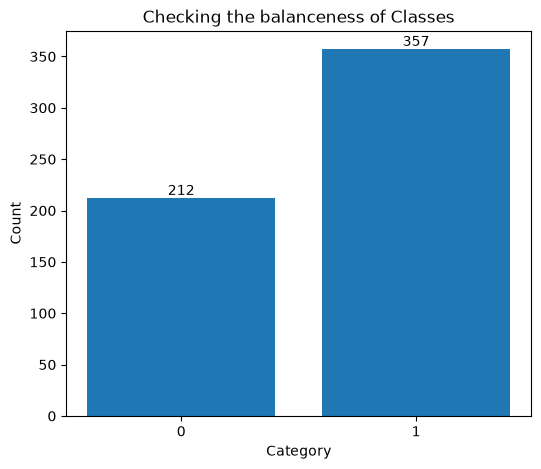

In [20]:
#checking the balanceness of the data
count_category = y['Target'].value_counts()

plt.figure(figsize=(6,5))
bars = plt.bar(count_category.index, count_category.values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Checking the balanceness of Classes")
plt.xticks([0, 1])
plt.bar_label(bars)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [26]:
print("Accuracy of the model:", accuracy_score(y_test, y_pred), end='\n\n')
print("Classification report:\n\n")
print(classification_report(y_test, y_pred))

Accuracy of the model: 0.9574468085106383

Classification report:


              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.96      0.98      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.95      0.95       188
weighted avg       0.96      0.96      0.96       188



In [27]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 62,   5],
       [  3, 118]])

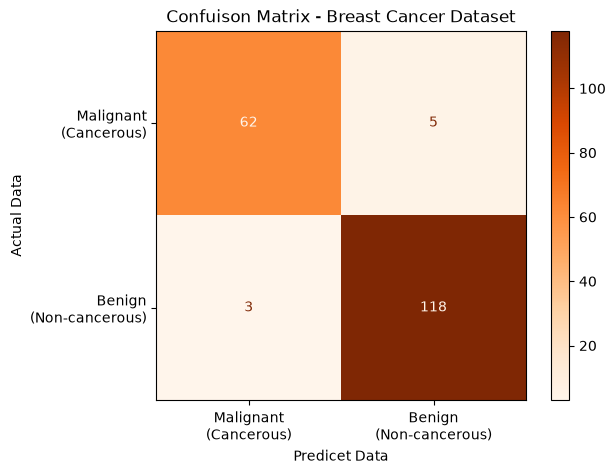

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ["Malignant\n(Cancerous)", "Benign\n(Non-cancerous)"], cmap='Oranges')
plt.xlabel('Predicet Data')
plt.ylabel('Actual Data')
plt.title('Confuison Matrix - Breast Cancer Dataset')
plt.show()

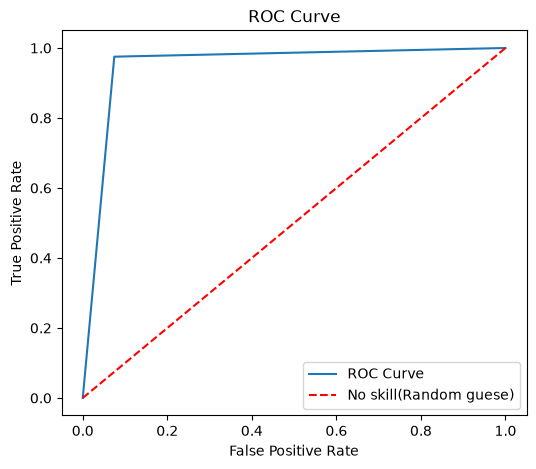

In [30]:
fpr, tpr, thresold = roc_curve(y_test, y_pred)
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--', label='No skill(Random guese)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


Top 10 Features:
worst concave points    0.140608
mean concave points     0.132638
worst area              0.125211
mean concavity          0.088845
worst perimeter         0.083761
worst radius            0.047649
mean radius             0.046295
mean perimeter          0.044979
area error              0.039836
mean area               0.039784
dtype: float64


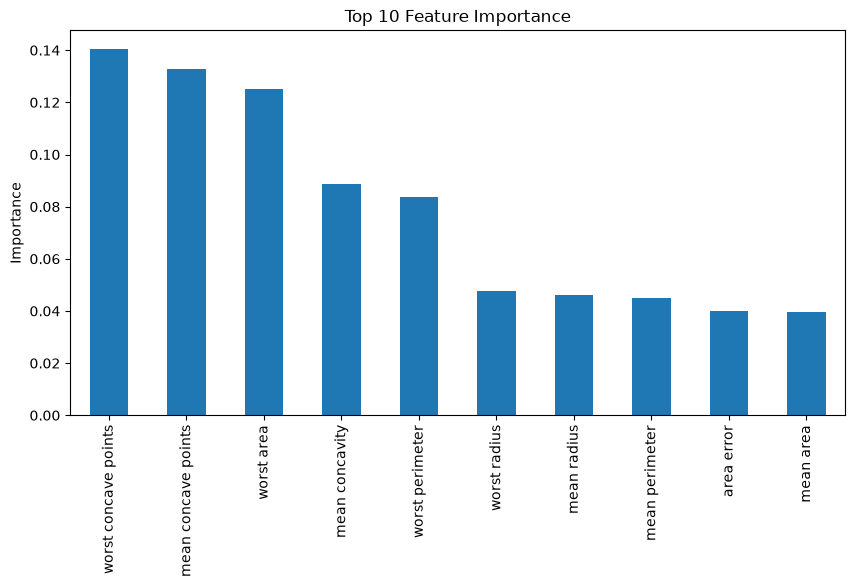

In [31]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop 10 Features:")
print(importance.head(10))

importance.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Feature Importance")
plt.ylabel("Importance")
plt.show()